In [1]:
# 1st cell - Hash
# run this one to generate hash - you'll need it for the next cell

import hashlib

filename = 'database.csv' 

def get_file_hash(path):
    
    sha256_hash = hashlib.sha256()
    with open(path, "rb") as f:
        
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

# Generate and print the result
try:
    
    print(f"File: {filename}")
    print(f"SHA-256 Hash: {get_file_hash(filename)}") # Copy the hash and paste it into 'EXPECTED_HASH' variable.
    print("-" * 30)
    
except FileNotFoundError:
    print(f"Error: '{filename}' not found.")

File: database.csv
SHA-256 Hash: a83ae7f10e647eba3edf9d899fcb32b1e450fcb5194365c4a93c470fd4b6c86d
------------------------------


In [3]:
# 2nd cell
# This will be the auditor, checking the integrity of the file

import hashlib
import os

# STEP 1: The 'Protection Profile' 
# Make sure this matches the output you got from the 1st cell!
EXPECTED_HASH = "a83ae7f10e647eba3edf9d899fcb32b1e450fcb5194365c4a93c470fd4b6c86d"
filename = 'database.csv'

def run_integrity_audit():
    # A. THE AVAILABILITY CHECK
    # FIXED: Changed '{database.csv}' to '{filename}' (variable name)
    if not os.path.exists(filename):
        print(f"ALERT: Asset '{filename}' is missing! Integrity cannot be verified.")
        return

    # B. THE FINGERPRINTING
    sha256_hash = hashlib.sha256()
    try:
        with open(filename, "rb") as f:
            for byte_block in iter(lambda: f.read(4096), b""):
                sha256_hash.update(byte_block)
        current_hash = sha256_hash.hexdigest()
    except Exception as e:
        print(f"Error reading file: {e}")
        return
    
    # C. THE TECHNICAL CONTROL
    if current_hash == EXPECTED_HASH:
        print("Integrity Verified: The file is safe and has not been modified.")
    else:
        print("!!! INTEGRITY BREACH DETECTED !!!")
        print(f"Expected: {EXPECTED_HASH}")
        print(f"Current:  {current_hash}")
        print("The file has been tampered with by a Threat Agent.")

# Run the function
run_integrity_audit()

!!! INTEGRITY BREACH DETECTED !!!
Expected: a83ae7f10e647eba3edf9d899fcb32b1e450fcb5194365c4a93c470fd4b6c86d
Current:  3b8b0525a1b9675a53e32c5e9c65d81fb5c8a9756fce34d9547f40312ca70bdf
The file has been tampered with by a Threat Agent.


2 Ways to simulate
- with 'database' (csv file) attached,
    * hash it first with the first cell, 
    * input expected hash in the second cell
    * make changes to the csv file - directly (attack simulation)
        - 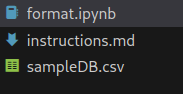
        - 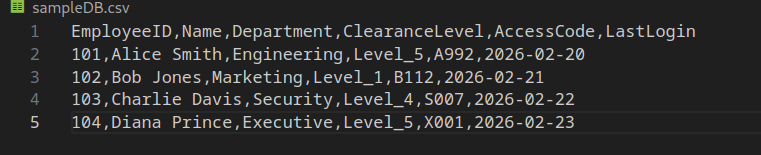,
    * hash it again with the first cell,
    * compare the two hashes

- same thing with above, but
    * make changes on a separate window (Excel, Spreadsheet, etc.)
    * reupload the csv file and rehash to see comparison (can also try renaming the file)